##### Import the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException
import re
import spacy
import nltk
from nltk.corpus import stopwords
import plotly.express as px
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import DistilBertTokenizer
from transformers import DistilBertForSequenceClassification
from transformers import TrainingArguments
from transformers import Trainer
from scipy.special import softmax
from huggingface_hub import login

nltk.download('punkt')
nltk.download('stopwords')



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\balog\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\balog\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

##### Load the dataset

In [2]:
df_clean = pd.read_csv(r'C:\Users\balog\OneDrive\Documents\Olayemi\Intership\Customer Feedback Analysis\Data\cleaned_reviews.csv')


##### Build a Transformer-based model (DistilBERT)

In [3]:
df_model = df_clean[["processed_review", "sentiment"]].copy()
df_model.head()

,processed_review,sentiment
0,register website try order laptop enter detail...,Negative
1,multiple order one turn driver phone door numb...,Negative
2,inform reprobate would go visit sick relative ...,Negative
3,buy amazon problem happy service price amazon ...,Negative
4,could give low rate would cancel amazon prime ...,Negative


- Encode Sentiment Labels

In [4]:
le = LabelEncoder()

df_model["sentiment_label"] = le.fit_transform(df_model["sentiment"])

df_model[["sentiment", "sentiment_label"]].head()

,sentiment,sentiment_label
0,Negative,0
1,Negative,0
2,Negative,0
3,Negative,0
4,Negative,0


- - Prepare Features and Target

In [5]:
X = df_model["processed_review"]
y = df_model["sentiment_label"]

- Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)

(16324,)
(4081,)


- Calculate Class Weights for imbalanced sentiments proportion

In [7]:
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights

array([0.48047093, 8.24444444, 1.25405239])

- Create Training DataFrames

In [8]:
train_db = pd.DataFrame({"text": X_train, "label": y_train})
test_db = pd.DataFrame({"text": X_test, "label": y_test})

- Convert to Hugging Face Dataset

In [9]:
train_dataset = Dataset.from_pandas(train_db)
test_dataset = Dataset.from_pandas(test_db)

- Tokenization

In [10]:
# Initialize the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# Tokenise the reviews
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

#Apply the tokenization function
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/16324 [00:00<?, ? examples/s]

Map:   0%|          | 0/4081 [00:00<?, ? examples/s]

- Train the Distilbert model

In [11]:
# Initialize the model
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

# Define Evaluation Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {"accuracy": accuracy_score(labels, preds),
        "precision_weighted": precision_score(labels, preds, average="weighted"),
        "recall_weighted": recall_score(labels, preds, average="weighted"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "f1_macro": f1_score(labels, preds, average="macro"),}


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


- Fine-tune DistilBERT

Epoch,Training Loss,Validation Loss,Accuracy,Precision Weighted,Recall Weighted,F1 Weighted,F1 Macro
1,0.307926,0.298238,0.909336,0.882997,0.909336,0.891146,0.616445
2,0.242272,0.323913,0.912031,0.891963,0.912031,0.897846,0.640115
3,0.174509,0.335973,0.913747,0.897314,0.913747,0.903985,0.664412


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT Results
Accuracy: 0.9093
Precision (Weighted): 0.8830
Recall (Weighted): 0.9093
F1 Score (Weighted): 0.8911
F1 Score (Macro): 0.6164
ROC-AUC: 0.9572

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      2831
           1       0.22      0.01      0.02       165
           2       0.91      0.85      0.88      1085

    accuracy                           0.91      4081
   macro avg       0.68      0.62      0.62      4081
weighted avg       0.88      0.91      0.89      4081


Confusion Matrix:


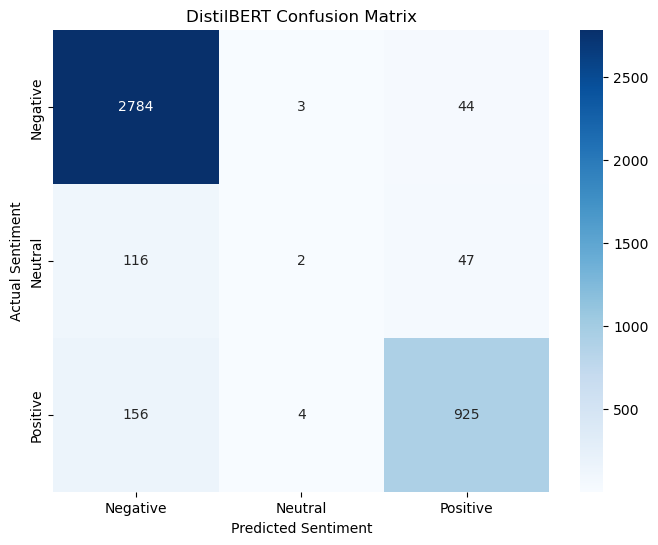

In [12]:
# Create a Trainer instance
training_args = TrainingArguments(output_dir="./results", eval_strategy="epoch", save_strategy="epoch", learning_rate=2e-5, per_device_train_batch_size=16, 
                                  per_device_eval_batch_size=16, num_train_epochs=3, weight_decay=0.01, load_best_model_at_end=True, dataloader_pin_memory=False)

# Fine-tune the model using the Trainer API
trainer = Trainer(model=model, args=training_args, train_dataset=train_dataset, eval_dataset=test_dataset, compute_metrics=compute_metrics)
trainer.train()

# Predictions
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_prob = softmax(predictions.predictions, axis=1)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision_weighted = precision_score(y_test, y_pred, average="weighted")
recall_weighted = recall_score(y_test, y_pred, average="weighted")
f1_weighted = f1_score(y_test, y_pred, average="weighted")
f1_macro = f1_score(y_test, y_pred, average="macro")
roc_auc = roc_auc_score( y_test, y_prob, multi_class="ovr", average="weighted")
report = classification_report(y_test, y_pred, zero_division=0)
matrix = confusion_matrix(y_test, y_pred)

# Print Results
print("=" * 50)
print("DistilBERT Results")
print("=" * 50)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(report)

print("\nConfusion Matrix:")
matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Neutral", "Positive"], yticklabels=["Negative", "Neutral", "Positive"])
plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()


     The DistilBERT model learned effectively over the three epochs and achieved its best performance in Epoch 3. With over 91% accuracy and consistent improvements in Precision, Recall, and F1-score, it clearly outperformed the baseline models (Naïve Bayes, Logistic Regression, and SVM

     DistilBERT achieved an overall Accuracy of 91.33% and ROC-AUC of 95.78%, making it the best-performing model. The high Weighted Precision (89.79%), Weighted Recall (91.33%), and Weighted F1-score (90.38%) show that the model performs very well across the majority of reviews. Correctly predicted 2,777 negative reviews, 930 positive reviews. It correctly classified only 1 out of 165 Neutral reviews, resulting in a very low Macro F1-score (67.19%) despite its strong overall performance. DistilBERT is the recommended final model because it delivers the highest accuracy and best overall classification performance

- Save final DistiBERT model


In [13]:
model.save_pretrained("distilbert_sentiment_model")

tokenizer.save_pretrained("distilbert_sentiment_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('distilbert_sentiment_model\\tokenizer_config.json',
 'distilbert_sentiment_model\\tokenizer.json')

In [14]:
model = DistilBertForSequenceClassification.from_pretrained("distilbert_sentiment_model")

tokenizer = DistilBertTokenizer.from_pretrained("distilbert_sentiment_model")

print("Model loaded successfully!")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded successfully!
